In [1]:
from typing import override
from pprint import pprint
import math
import numpy as np
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
import matplotlib.pyplot as plt

from systrade import (
    BacktestBroker,
    BarData,
    Engine,
    ExecutionReport,
    FileFeed,
    Strategy,
)

In [ ]:
class StatArbStrategy(Strategy):
    def __init__(self, symbol_a, symbol_b, window=60, entry_z=2.0, exit_z=0.5, starting_cash=10000):
        super().__init__()
        self.symbol_a = symbol_a
        self.symbol_b = symbol_b
        self.window = window
        self.entry_z = entry_z
        self.exit_z = exit_z
        self.prices_a = []
        self.prices_b = []
        self.spread_position = None
        self.available_cash = starting_cash
        # track positions manually to avoid LivePortfolioView error
        self.qty_a = 0.0
        self.qty_b = 0.0
        self.equity_history = []
        self.date_history = []


    @override
    def on_start(self):
        self.subscribe(self.symbol_a)
        self.subscribe(self.symbol_b)

    @override
    def on_data(self, data: BarData):
        if self.symbol_a not in data.symbols() or self.symbol_b not in data.symbols():
            return

        price_a = data[self.symbol_a].close
        price_b = data[self.symbol_b].close

        self.prices_a.append(price_a)
        self.prices_b.append(price_b)

        if len(self.prices_a) < self.window:
            return

        pa = np.array(self.prices_a[-self.window:])
        pb = np.array(self.prices_b[-self.window:])
        beta = OLS(pa, add_constant(pb)).fit().params[1]

        spread = pa - beta * pb
        spread_mean = spread.mean()
        spread_std = spread.std()

        if spread_std == 0:
            return

        current_spread = price_a - beta * price_b
        z_score = (current_spread - spread_mean) / spread_std

        # --- Exit long spread ---
        if self.spread_position == "long" and abs(z_score) < self.exit_z:
            if self.qty_a != 0:
                self.post_market_order(self.symbol_a, -self.qty_a)
                self.available_cash += self.qty_a * price_a
                self.qty_a = 0.0
            if self.qty_b != 0:
                self.post_market_order(self.symbol_b, -self.qty_b)
                self.available_cash += abs(self.qty_b) * price_b
                self.qty_b = 0.0
            self.spread_position = None
            print(f"EXIT long spread | z={z_score:.2f}")

        # --- Exit short spread ---
        elif self.spread_position == "short" and abs(z_score) < self.exit_z:
            if self.qty_a != 0:
                self.post_market_order(self.symbol_a, -self.qty_a)
                self.available_cash += abs(self.qty_a) * price_a
                self.qty_a = 0.0
            if self.qty_b != 0:
                self.post_market_order(self.symbol_b, -self.qty_b)
                self.available_cash += self.qty_b * price_b
                self.qty_b = 0.0
            self.spread_position = None
            print(f"EXIT short spread | z={z_score:.2f}")

        # --- Entry ---
        elif self.spread_position is None:
            half_cash = self.available_cash * 0.5
            if half_cash <= 0:
                return

            if z_score < -self.entry_z:
                self.qty_a = half_cash / price_a
                self.qty_b = -(half_cash / price_b)
                self.post_market_order(self.symbol_a, self.qty_a)
                self.post_market_order(self.symbol_b, self.qty_b)
                self.available_cash -= (abs(self.qty_a) * price_a + abs(self.qty_b) * price_b)
                self.spread_position = "long"
                print(f"ENTER long spread | z={z_score:.2f}")

            elif z_score > self.entry_z:
                self.qty_a = -(half_cash / price_a)
                self.qty_b = half_cash / price_b
                self.post_market_order(self.symbol_a, self.qty_a)
                self.post_market_order(self.symbol_b, self.qty_b)
                self.available_cash -= (abs(self.qty_a) * price_a + abs(self.qty_b) * price_b)
                self.spread_position = "short"
                print(f"ENTER short spread | z={z_score:.2f}")

        current_value = self.available_cash + self.qty_a*price_a + self.qty_b*price_b
        self.equity_history.append(current_value)
        self.date_history.append(data.as_of)
    @override
    def on_execution(self, report: ExecutionReport):
        print("Execution:")
        pprint(report, indent=2)

In [3]:
cash = 1000000
feed = FileFeed("history.csv", start="2022-01-01", end="2024-1-1")
broker = BacktestBroker()
strategy = StatArbStrategy("NVDA", "GME", starting_cash=cash)
engine = Engine(feed, broker, strategy, cash)
engine.run()

ENTER long spread | z=-2.04
Execution:
ExecutionReport(order=Order(id='cd80a4ee-243a-4c10-be9b-7685f6bef0a3',
                            symbol='NVDA',
                            quantity=np.float64(21664.22940229242),
                            type=<OrderType.MARKET: 1>,
                            submit_time=datetime.datetime(2022, 4, 8, 0, 0, tzinfo=<DstTzInfo 'America/New_York' EDT-1 day, 20:00:00 DST>),
                            price=None),
                last_price=np.float64(22.17606754119229),
                last_quantity=np.float64(21664.22940229242),
                cum_quantity=np.float64(21664.22940229242),
                rem_quantity=0.0,
                fill_timestamp=datetime.datetime(2022, 4, 11, 0, 0, tzinfo=<DstTzInfo 'America/New_York' EDT-1 day, 20:00:00 DST>))
Execution:
ExecutionReport(order=Order(id='fdc4c4a0-18d7-4fec-b3d2-e2e35d33bb53',
                            symbol='GME',
                            quantity=np.float64(-13680.826093436935),
   

In [ ]:
print(type(engine.portfolio))
print(type(engine._broker))

In [4]:
# Since engine.portfolio.activity() doesn't work with BacktestBroker,
# we compute performance manually from our tracked positions

final_price_a = feed.df.loc[strategy.symbol_a]["Close"].iloc[-1]
final_price_b = feed.df.loc[strategy.symbol_b]["Close"].iloc[-1]

# Final portfolio value = cash + value of any open positions
final_value = strategy.available_cash
if strategy.qty_a != 0:
    final_value += strategy.qty_a * final_price_a
if strategy.qty_b != 0:
    final_value += strategy.qty_b * final_price_b

total_return = (final_value - cash) / cash

print(f"Starting Cash:  ${cash:,.2f}")
print(f"Final Value:    ${final_value:,.2f}")
print(f"Total Return:   {total_return:.2%}")

Starting Cash:  $1,000,000.00
Final Value:    $1,341,241.43
Total Return:   34.12%


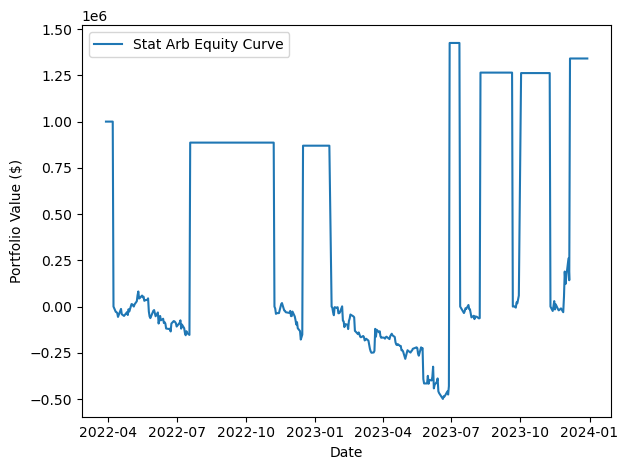

In [5]:
fig, ax = plt.subplots()
ax.plot(strategy.date_history, strategy.equity_history, label="Stat Arb Equity Curve")
ax.set_xlabel("Date")
ax.set_ylabel("Portfolio Value ($)")
ax.legend()
fig.tight_layout()
plt.show()

In [6]:
import pandas as pd

gs = feed.df.loc["GME"]["Close"]
nvda = feed.df.loc["NVDA"]["Close"]

correlation = gs.corr(nvda)
print(f"Correlation: {correlation:.4f}")


Correlation: -0.5552


In [5]:
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame
from datetime import datetime
import pandas as pd

# Your Alpaca API keys
API_KEY = "PK6LOUEHUJFICHU2EG6MP2Z7ZP"
API_SECRET = "CvpguAv2MRHeCZGyGTWzx4ZyUgPjTjpsEvG5bLUBEqtf"

client = StockHistoricalDataClient(API_KEY, API_SECRET)

# Tech ETFs: XLK, QQQ, the rest are indexes i.e- S&P
request_params = StockBarsRequest(
    symbol_or_symbols=["XLK", "QQQ", "ITOT", "SPLV", "SPY", "VTI"],
    timeframe=TimeFrame.Day,       # use TimeFrame.Minute for minute bars
    start=datetime(2022, 1, 1),
    end=datetime(2025, 3, 31),
)

bars = client.get_stock_bars(request_params)
df = bars.df
print(df.head())

                                   open     high      low  close      volume  \
symbol timestamp                                                               
SPLV   2022-01-03 05:00:00+00:00  68.57  68.5700  67.3401  67.96  13091135.0   
       2022-01-04 05:00:00+00:00  68.00  68.4200  67.8888  68.01   4145113.0   
       2022-01-05 05:00:00+00:00  68.04  68.3753  67.6200  67.63   7918898.0   
       2022-01-06 05:00:00+00:00  67.66  67.9200  67.4700  67.53   6382114.0   
       2022-01-07 05:00:00+00:00  67.47  67.7550  67.2800  67.51   5634748.0   

                                  trade_count       vwap  
symbol timestamp                                          
SPLV   2022-01-03 05:00:00+00:00      25958.0  67.729662  
       2022-01-04 05:00:00+00:00      18051.0  68.141484  
       2022-01-05 05:00:00+00:00      29987.0  67.994238  
       2022-01-06 05:00:00+00:00      29772.0  67.653592  
       2022-01-07 05:00:00+00:00      26981.0  67.551981  


In [ ]:
df.to_csv("trading_comp_data.csv")

In [7]:
import pandas as pd
import numpy as np

gs = feed.df.loc["GS"]["Close"]
nvda = feed.df.loc["NVDA"]["Close"]

# 1. Correlation
print(f"Correlation: {gs.corr(nvda):.4f}")

# 2. Number of trades — too few means the return is based on luck
print(f"Total trades entered: {len([x for x in strategy.equity_history if x != strategy.equity_history[0]])}")

# 3. Max drawdown — how much did you lose at the worst point
equity = pd.Series(strategy.equity_history)
rolling_max = equity.cummax()
drawdown = (equity - rolling_max) / rolling_max
print(f"Max Drawdown: {drawdown.min():.2%}")

Correlation: -0.0603
Total trades entered: 156
Max Drawdown: -115.83%


In [ ]:
import pandas as pd 
df = pd.read_csv("trading_comp_data.csv")

In [10]:
print(df.head())
print(df.columns.to_list())

                                   open     high      low  close      volume  \
symbol timestamp                                                               
SPLV   2022-01-03 05:00:00+00:00  68.57  68.5700  67.3401  67.96  13091135.0   
       2022-01-04 05:00:00+00:00  68.00  68.4200  67.8888  68.01   4145113.0   
       2022-01-05 05:00:00+00:00  68.04  68.3753  67.6200  67.63   7918898.0   
       2022-01-06 05:00:00+00:00  67.66  67.9200  67.4700  67.53   6382114.0   
       2022-01-07 05:00:00+00:00  67.47  67.7550  67.2800  67.51   5634748.0   

                                  trade_count       vwap  
symbol timestamp                                          
SPLV   2022-01-03 05:00:00+00:00      25958.0  67.729662  
       2022-01-04 05:00:00+00:00      18051.0  68.141484  
       2022-01-05 05:00:00+00:00      29987.0  67.994238  
       2022-01-06 05:00:00+00:00      29772.0  67.653592  
       2022-01-07 05:00:00+00:00      26981.0  67.551981  
['open', 'high', 'low', 'c

In [20]:
df_reset = df.reset_index()
df_reset = df_reset.rename(columns={"timestamp": "Date"})
df_reset = df_reset.rename(columns={"symbol": "Symbol"})

In [ ]:
print(df_reset.head())
print(df_reset.columns.to_list())


  Symbol                      Date   open     high      low  close  \
0   SPLV 2022-01-03 05:00:00+00:00  68.57  68.5700  67.3401  67.96   
1   SPLV 2022-01-04 05:00:00+00:00  68.00  68.4200  67.8888  68.01   
2   SPLV 2022-01-05 05:00:00+00:00  68.04  68.3753  67.6200  67.63   
3   SPLV 2022-01-06 05:00:00+00:00  67.66  67.9200  67.4700  67.53   
4   SPLV 2022-01-07 05:00:00+00:00  67.47  67.7550  67.2800  67.51   

       volume  trade_count       vwap  
0  13091135.0      25958.0  67.729662  
1   4145113.0      18051.0  68.141484  
2   7918898.0      29987.0  67.994238  
3   6382114.0      29772.0  67.653592  
4   5634748.0      26981.0  67.551981  
['Symbol', 'Date', 'open', 'high', 'low', 'close', 'volume', 'trade_count', 'vwap']


In [ ]:
df_reset.to_csv("trading_comp_data2.csv")

In [11]:
df2 = pd.read_csv("history.csv")

In [12]:
print(df2.head())
print(df2.columns.to_list())

                        Date         Open         High          Low  \
0  2005-01-03 00:00:00-05:00  1211.920044  1217.800049  1200.319946   
1  2005-01-04 00:00:00-05:00  1202.079956  1205.839966  1185.390015   
2  2005-01-05 00:00:00-05:00  1188.050049  1192.729980  1183.719971   
3  2005-01-06 00:00:00-05:00  1183.739990  1191.630005  1183.270020   
4  2005-01-07 00:00:00-05:00  1187.890015  1192.199951  1182.160034   

         Close      Volume  Dividends  Stock Splits Symbol  
0  1202.079956  1510800000        0.0           0.0  ^GSPC  
1  1188.050049  1721000000        0.0           0.0  ^GSPC  
2  1183.739990  1738900000        0.0           0.0  ^GSPC  
3  1187.890015  1569100000        0.0           0.0  ^GSPC  
4  1186.189941  1477900000        0.0           0.0  ^GSPC  
['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits', 'Symbol']
